# Text to Image
___

#### Library

In [12]:
# Library Import
import os
import clip
from PIL import Image
import nltk
import torch
import matplotlib.pyplot as plt

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')  # Download the English words corpus

# Initialize lemmatizer, stemmer, and stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords, words

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
STOP_WORDS = set(stopwords.words('english'))
ENGLISH_WORDS = set(words.words())  # Set of valid English words

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Patrick\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


#### Code

In [13]:
# Define the function to process documents
def is_english_word(word):
    return word.lower() in ENGLISH_WORDS

def processed_documents(query):
    """Process query text: lemmatize, remove stopwords, and stem."""
    words_list = query.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in words_list]
    filtered = [word for word in lemmatized if word not in STOP_WORDS and is_english_word(word)]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed)

# Load CLIP Model
def load_clip_model(device='cpu'):
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    return clip_model, clip_preprocess

# Process the query text
def process_query(query_text):
    processed_query = processed_documents(query_text)
    return processed_query

# Batch process images and compute similarities
def best_matching_image(query_text, image_folder, batch_size=50, clip_device='cuda'):
    clip_model, clip_preprocess = load_clip_model(device=clip_device)

    # Preprocess the query text
    processed_query = process_query(query_text)

    # Tokenize and encode the query text
    text_input = clip.tokenize([processed_query]).to(clip_device)
    text_features = clip_model.encode_text(text_input).detach()
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # List all images in the folder
    image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]

    best_match_image = None
    best_match_score = -float('inf')

    # Process images in batches
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        images = [clip_preprocess(Image.open(img_path)).unsqueeze(0).to(clip_device) for img_path in batch_paths]

        # Stack images in a batch
        images_batch = torch.cat(images, dim=0)

        # Encode images
        image_features = clip_model.encode_image(images_batch).detach()
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Calculate similarity between the query text and image features
        similarities = (text_features @ image_features.T).squeeze(0)

        # Get top matching image from the batch
        top_index = similarities.argmax().item()
        best_similarity = similarities[top_index].item()

        # Check if this is the best match so far
        if best_similarity > best_match_score:
            best_match_score = best_similarity
            best_match_image = batch_paths[top_index]

    return best_match_image, best_match_score

In [14]:
def text_to_image_search():
    # Prompt the user for the query text
    query_text = input("Query Text: ")

    # Define the image folder (you can modify this as needed)
    image_folder = "Testing Images"

    # Get the best matching image and score
    best_image, score = best_matching_image(query_text, image_folder)

    # Show the result
    print(f"Best Image: \n{best_image} \nSimiliarity Score: \n{score}")

    # Display the best matching image
    img = Image.open(best_image)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()

#### Execute Code

Query Text:  Forest


Best Image: 
Testing Images\IMG_2721.jpg 
Similiarity Score: 
0.27099609375


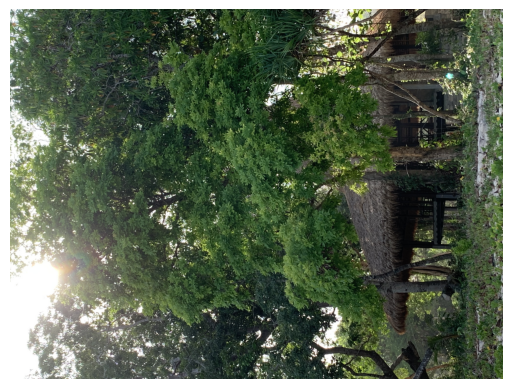

In [7]:
text_to_image_search()

Query Text:  Tower


Best Image: 
Testing Images\IMG_2725.jpg 
Similiarity Score: 
0.261474609375


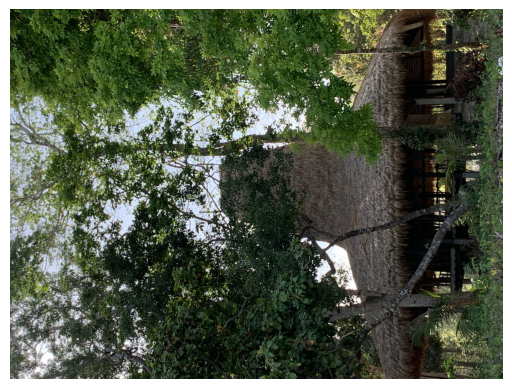

In [9]:
text_to_image_search()

Query Text:  Airport


Best Image: 
Testing Images\1-3-scaled.jpg 
Similiarity Score: 
0.252685546875


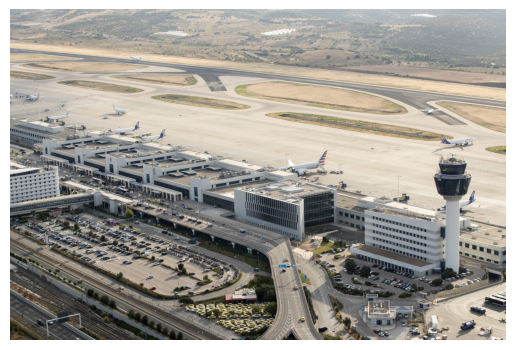

In [10]:
text_to_image_search()

Query Text:  Pottery Workshop


Best Image: 
Testing Images\2x Vintage Ancient Hellenistic Cyples Style Chalky Clay Vase Rustic Home Decor.jpg 
Similiarity Score: 
0.28466796875


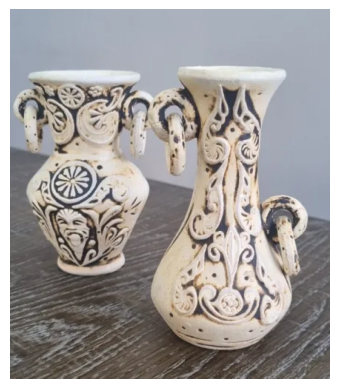

In [11]:
text_to_image_search()

Query Text:  Uncanny remember certain mode something something past failing chasing ghost past present future absolutely political critique Many public shopping also pleasant social musical theatrical farm 


Best Image: 
Testing Images\Ba Sing Se.jpg 
Similiarity Score: 
0.2396240234375


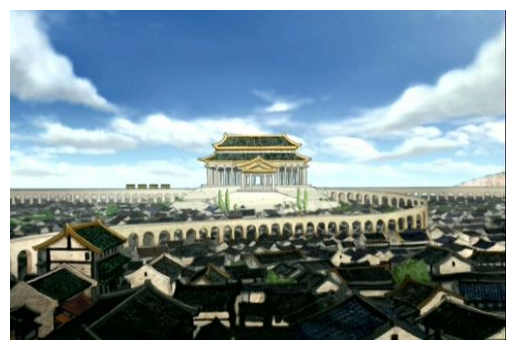

In [15]:
text_to_image_search()

#### Image Library

In [36]:
def image_keywords(image_path, all_keywords_features, possible_keywords, clip_model, clip_preprocess, clip_device, top_n=10):
    """
    Generate keywords for a single image, sorted by similarity to the image.
    Only returns the top `top_n` keywords.
    """
    # Load and preprocess the image
    image = clip_preprocess(Image.open(image_path)).unsqueeze(0).to(clip_device)

    # Encode the image
    image_features = clip_model.encode_image(image).detach()
    image_features /= image_features.norm(dim=-1, keepdim=True)

    # Calculate similarity between the image and all keyword features
    similarities = (image_features @ all_keywords_features.T).squeeze(0)

    # Debugging: Print raw similarities
    print(f"Raw similarities for {image_path}: {similarities}")

    # Sort keywords by similarity
    sorted_indices = torch.argsort(similarities, descending=True)

    # Select the top `top_n` keywords
    sorted_keywords = [possible_keywords[idx] for idx in sorted_indices.cpu().numpy()[:top_n]]

    return sorted_keywords


def process_images_in_folder(image_folder, pickle_folder="Pickle", output_pickle="Image_Library.pkl", top_n=10):
    # Set up the CLIP model
    clip_device = "cuda" if torch.cuda.is_available() else "cpu"
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=clip_device)

    # Load preprocessed text features
    keywords_features_path = os.path.join(pickle_folder, "Keywords_Token.pkl")
    with open(keywords_features_path, "rb") as f:
        all_keywords_features = pickle.load(f).to(clip_device)

    # Load possible keywords
    all_keywords_pickle_path = os.path.join(pickle_folder, "All Keywords.pkl")
    with open(all_keywords_pickle_path, "rb") as f:
        possible_keywords = pickle.load(f)

    # Initialize the image-to-keywords mapping
    image_library = {}

    # Process each image in the folder
    for image_file in os.listdir(image_folder):
        if image_file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
            image_path = os.path.join(image_folder, image_file)

            # Generate sorted keywords for the image, limited to top_n
            sorted_keywords = image_keywords(image_path, all_keywords_features, possible_keywords, clip_model, clip_preprocess, clip_device, top_n)

            # Store the results
            image_library[image_file] = sorted_keywords
            print(f"Processed: {image_file}")

    # Save the image-to-keywords mapping to a pickle file
    with open(output_pickle, "wb") as f:
        pickle.dump(image_library, f)

    print(f"Image-to-keywords mapping saved to {output_pickle}")

In [37]:
# Update with your paths
image_folder_path = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images"
pickle_folder_path = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Pickle"
output_pickle_path = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Pickle\Image_Library.pkl"

process_images_in_folder(image_folder_path, pickle_folder_path, output_pickle_path)

Raw similarities for E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images\!!!! ANTIQUE FAYENCE TILES CERAMIC TILE!!!!!.jpg: tensor([0.2109, 0.2072, 0.2051,  ..., 0.2177, 0.1919, 0.2013], device='cuda:0',
       dtype=torch.float16)
Processed: !!!! ANTIQUE FAYENCE TILES CERAMIC TILE!!!!!.jpg
Raw similarities for E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images\!!!! ANTIQUE TILE ANGLER CERAMIC!!!!!.jpg: tensor([0.2034, 0.2253, 0.2321,  ..., 0.2291, 0.2101, 0.2219], device='cuda:0',
       dtype=torch.float16)
Processed: !!!! ANTIQUE TILE ANGLER CERAMIC!!!!!.jpg
Raw similarities for E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Testing Images\!!!!! ANTIQUE FAIENCE TILES CERAMIC TILE!!!!!.jpg: tensor([0.2119, 0.1926, 0.2124,  ..., 0.2225, 0.2031, 0.2095], device='cuda:0',
       dtype=torch.float16)
Processed: !!!!! ANTIQUE FAIENCE TILES CERAMIC TILE!!!!!.jpg
R

#### Pickle Check

In [20]:
# Define the path to the pickle file
file_path = os.path.join("Pickle","Keywords_Token.pkl")

# Load the pickle file
with open(file_path, "rb") as file:
    data = pickle.load(file)

# Ensure the data is in list format
if not isinstance(data, list):
    try:
        data = list(data)  # Convert to list if possible
    except TypeError:
        print("The data could not be converted to a list.")
        data = None

# Check the content of the data
if data is not None:
    print("The loaded data contains:")
    for i, item in enumerate(data[:10]):  # Display the first 10 items
        print(f"{i + 1}: {item}")
else:
    print("The data could not be loaded or is not iterable.")


The loaded data contains:
1: tensor([-1.1887e-02, -1.4435e-02,  4.7064e-04,  3.0777e-02, -1.1055e-02,
         4.7379e-03,  1.0147e-02, -9.6741e-02, -1.8509e-02,  4.1084e-03,
        -1.8753e-02,  4.0970e-03,  6.6605e-03, -3.2745e-02, -2.0676e-03,
        -1.0323e-02,  2.2980e-02,  4.4670e-03, -1.8784e-02, -2.5070e-02,
         3.4637e-02,  2.7939e-02,  1.4839e-02,  3.9856e-02,  2.0325e-02,
         2.9388e-02, -1.1169e-02, -6.1188e-03, -1.6937e-02, -8.3618e-03,
        -1.2566e-02,  1.0681e-02,  1.8600e-02, -1.6022e-02,  6.1035e-03,
         2.5314e-02,  9.2773e-03,  1.7746e-02,  1.1871e-02, -2.2064e-02,
         1.8967e-02,  1.1116e-02, -1.6464e-02, -6.6757e-04,  1.7944e-02,
         9.5291e-03, -2.7802e-02,  1.1688e-02,  7.6447e-03,  1.6937e-02,
        -4.0474e-03, -1.0727e-02,  1.9197e-03,  1.1225e-03,  4.0283e-03,
        -1.3306e-02, -2.9175e-02, -6.0310e-03,  2.1927e-02, -3.1113e-02,
         1.2733e-02, -1.1139e-02,  9.6436e-03, -2.7283e-02,  1.2115e-02,
         8.0795e-03, -

In [21]:
# Define the path to the pickle file
file_path = os.path.join("Pickle","Image_Library.pkl")

# Load the pickle file
with open(file_path, "rb") as file:
    data = pickle.load(file)

# Ensure the data is in list format
if not isinstance(data, list):
    try:
        data = list(data)  # Convert to list if possible
    except TypeError:
        print("The data could not be converted to a list.")
        data = None

# Check the content of the data
if data is not None:
    print("The loaded data contains:")
    for i, item in enumerate(data[:10]):  # Display the first 10 items
        print(f"{i + 1}: {item}")
else:
    print("The data could not be loaded or is not iterable.")


The loaded data contains:
1: !!!! ANTIQUE FAYENCE TILES CERAMIC TILE!!!!!.jpg
2: !!!! ANTIQUE TILE ANGLER CERAMIC!!!!!.jpg
3: !!!!! ANTIQUE FAIENCE TILES CERAMIC TILE!!!!!.jpg
4: 1 of 7 Vintage Wedgwood Home Aztec Dinner Plates 10 1_2in Diameter Excellent E.jpg
5: 1-3-scaled.jpg
6: 2 Ancient Roman Replica Ceramic Pottery Vessels - 1 Signed S.C.O. Orvieto Italy.jpg
7: 2 Antique Tea Bowls & Saucers Dawson of Sunderland J.15..jpg
8: 2 Art Nouveau vase ceramic side vases pair art noveau porcelain fiori vaso.jpg
9: 2 X Johnson Brothers England Ancient Towers  10” Dinner Plates  Blue.jpg
10: 2 x Vintage Decorative Ancient Greece Painted Plate - Clay Wall Hanging Set.jpg


In [14]:
import pickle

# Load the Image Library pickle file
pickle_path = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_SkillsClasses\Workshop2\Pickle\Image_Library.pkl"
with open(pickle_path, "rb") as f:
    image_library = pickle.load(f)

# Check the first few items in the image_library
for image_file, keywords in list(image_library.items())[:200]:  # Show the first 5 images
    print(f"Image: {image_file}, Keywords: {keywords[:50]}")  # Show first 10 keywords for each image

Image: !!!! ANTIQUE FAYENCE TILES CERAMIC TILE!!!!!.jpg, Keywords: ['unmarti', 'agricol', 'wippen', 'weatherhead', 'clyster', 'restrict', 'tableland', 'sprayer', 'mainland', 'cubiculum', 'likeli', 'ginseng', 'tractil', 'fondli', 'braw', 'accommod', 'lividli', 'avast', 'heteromer', 'algarroba', 'unexpect', 'cordilleran', 'hubbl', 'trait', 'playboy', 'surfac', 'ministri', 'absquatul', 'dumbl', 'spermatozoon', 'multicolor', 'forti', 'entrapp', 'goof', 'prohibitionist', 'trundl', 'alloy', 'gloriou', 'yarrow', 'roadster', 'enthusiasm', 'servitor', 'chronometr', 'unguid', 'squawk', 'sudder', 'dichlorid', 'sawlik', 'ampulla', 'knowledg']
Image: !!!! ANTIQUE TILE ANGLER CERAMIC!!!!!.jpg, Keywords: ['wippen', 'restrict', 'cubiculum', 'hubbl', 'nagana', 'metalog', 'clyster', 'rhesu', 'certainti', 'flapjack', 'feudal', 'tweet', 'semiautonom', 'flatteri', 'apiari', 'akamatsu', 'tois', 'oint', 'putat', 'braw', 'dichlorid', 'icebound', 'bet', 'spinner', 'exaggeratedli', 'yarrow', 'touchless', 'tourn

In [15]:
import pandas as pd

# Convert the image_library dictionary into a DataFrame
df = pd.DataFrame([(image_file, ", ".join(keywords[:50])) for image_file, keywords in image_library.items()],
                  columns=["Image", "Top Keywords"])

# Display the DataFrame
df.head(200)  # Show the first 10 rows of the DataFrame

,Image,Top Keywords
0,!!!! ANTIQUE FAYENCE TILES CERAMIC TILE!!!!!.jpg,"unmarti, agricol, wippen, weatherhead, clyster..."
1,!!!! ANTIQUE TILE ANGLER CERAMIC!!!!!.jpg,"wippen, restrict, cubiculum, hubbl, nagana, me..."
2,!!!!! ANTIQUE FAIENCE TILES CERAMIC TILE!!!!!.jpg,"unrefin, lividli, braw, cadmium, manumit, guij..."
3,1 of 7 Vintage Wedgwood Home Aztec Dinner Plat...,"metalog, clyster, closter, beryl, cubiculum, c..."
4,1-3-scaled.jpg,"radiolog, unenerget, arguabl, marzipan, frow, ..."
...,...,...
105,_vintage Livia Gorka ceramic vase studio ceram...,"masseus, inducte, incarnadin, chrome, tourney,..."
106,_Wheel Vase by Louis Hudson for Cornish Studio...,"crotonaldehyd, biotic, unimped, trichothal, qu..."
107,"__ Rare MAX LAEUGER Vase, Clay Works Kandern C...","silicon, clyster, imprest, counti, puritano, t..."
108,“ La Cañaza” Sur De La Peninsula De Azuero Anc...,"disobedi, col, unimped, blip, changeless, iron..."
